In [11]:
import networkx as nx
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

In [12]:
df = pd.read_csv("nodes.csv")
df2 = pd.read_csv("network_nodes_train.csv")

G = nx.Graph()

# get set of nodes that should be red
red_nodes = set(df2["name"])

for _, row in df.iterrows():
    node_name = row["name"]
    
    color = "red" if node_name in red_nodes else "blue"
    
    G.add_node(
        node_name,
        station=row["station"],
        lat=row["lat"],
        lng=row["lng"],
        color=color
    )

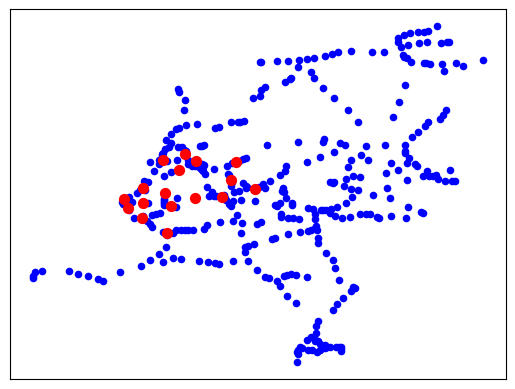

In [13]:
pos = {
    node: (data["lng"], data["lat"])
    for node, data in G.nodes(data=True)
}

red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]
blue_nodes = [n for n in G.nodes() if G.nodes[n]["color"] != "red"]

# draw blue first
nx.draw_networkx_nodes(
    G, pos,
    nodelist=blue_nodes,
    node_color="blue",
    node_size=20
)

# draw red on top
nx.draw_networkx_nodes(
    G, pos,
    nodelist=red_nodes,
    node_color="red",
    node_size=50
)

In [14]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    lon1 = np.radians(lon1)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [15]:
lat1, lon1 = G.nodes["SHL"]["lat"], G.nodes["SHL"]["lng"]
lat2, lon2 = G.nodes["RTD"]["lat"], G.nodes["RTD"]["lng"]

print(f"SHL: ({lat1}, {lon1})")
print(f"RTD: ({lat2}, {lon2})")
dist_scale = haversine(lat1, lon1, lat2, lon2)
time_scale = 27 # minutes from SHL to RTD

km_to_time = time_scale / dist_scale
print(km_to_time)

SHL: (52.30944442749, 4.7619442939758)
RTD: (51.92499923706, 4.468888759613)
0.572039773582883


In [16]:
edges_df = pd.read_csv("edges.csv")

for _, row in edges_df.iterrows():
    n1 = row["from"]
    n2 = row["to"]

    lat1, lon1 = G.nodes[n1]["lat"], G.nodes[n1]["lng"]
    lat2, lon2 = G.nodes[n2]["lat"], G.nodes[n2]["lng"]

    dist = haversine(lat1, lon1, lat2, lon2)
    travel_time = dist * km_to_time

    G.add_edge(n1, n2, weight=travel_time)

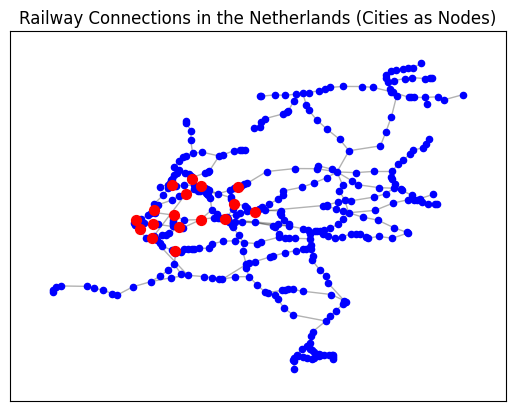

In [17]:
import matplotlib.pyplot as plt
# edges
nx.draw_networkx_edges(G, pos, alpha=0.3)

# nodes (layered)
nx.draw_networkx_nodes(G, pos, nodelist=blue_nodes, node_color="blue", node_size=20)
nx.draw_networkx_nodes(G, pos, nodelist=red_nodes, node_color="red", node_size=50)
plt.title("Railway Connections in the Netherlands (Cities as Nodes)")
plt.savefig("network_graph.png", dpi=300)
plt.show()

In [18]:
# all red cities
red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]

results = []

for source, target in itertools.combinations(red_nodes, 2):
    try:
        path = nx.shortest_path(G, source=source, target=target, weight="weight")
        distance = nx.shortest_path_length(G, source=source, target=target, weight="weight")

        results.append({
            "from": source,
            "to": target,
            "travel_time": distance,
            "path": path
        })
    except nx.NetworkXNoPath:
        results.append({
            "from": source,
            "to": target,
            "travel_time": None,
            "path": None
        })

shortest_paths_df = pd.DataFrame(results)

In [19]:
row = shortest_paths_df[
    (shortest_paths_df["from"] == "DDR") &
    (shortest_paths_df["to"] == "UT")
]

print(row)              # full row
print(row["path"])      # just the path column

   from  to  travel_time                                               path
87  DDR  UT    40.355759  [DDR, ZWD, BRD, RLB, RTZ, RTB, RTD, RTN, RTA, ...
87    [DDR, ZWD, BRD, RLB, RTZ, RTB, RTD, RTN, RTA, ...
Name: path, dtype: object


In [20]:
red_set = set(red_nodes)

direct_connections = []

for _, row in shortest_paths_df.iterrows():
    path = row["path"]
    
    if path is None:
        continue

    # only check intermediate nodes, not start/end
    intermediate_nodes = path[1:-1]

    # keep only if all intermediate nodes are blue
    if all(node not in red_set for node in intermediate_nodes):
        direct_connections.append({
            "from": row["from"],
            "to": row["to"],
            "travel_time": row["travel_time"],
            "path": path
        })

red_city_connections_df = pd.DataFrame(direct_connections)

In [21]:
print(red_city_connections_df)

    from    to  travel_time                                               path
0    ALM   ASD    14.957857        [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD]
1    ALM   HVS    10.915611            [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS]
2    ALM   SHL    19.805133   [ALM, ALMM, AMPO, WP, DMNZ, DVD, RAI, ASDZ, SHL]
3    APN    GD     8.472991              [APN, BSK, BSKS, WADN, WAD, WADT, GD]
4    APN  LEDN     7.899920                                   [APN, LDL, LEDN]
5    APN    WD    10.175796                                     [APN, BDG, WD]
6    AMF   HVS     8.934574                                    [AMF, BRN, HVS]
7    AMF    UT    11.515095                           [AMF, DLD, BHV, UTO, UT]
8    ASD   HLM    10.300491                        [ASD, ASS, HWZB, HLMS, HLM]
9    ASD   HVS    15.476281   [ASD, ASDM, ASSP, DMN, WP, NDB, BSMZ, HVSM, HVS]
10   ASD   SHL     6.957514                                         [ASD, SHL]
11   ASD    UT    21.492884  [ASD, ASDM, ASA, DVD, A

{'ALM': Text(5.21764, 52.37503, 'ALM'),
 'APN': Text(4.6577777862549, 52.124443054199, 'APN'),
 'AMF': Text(5.3705554008484, 52.153888702393, 'AMF'),
 'ASD': Text(4.9002776145935, 52.378887176514, 'ASD'),
 'DT': Text(4.3563890457153, 52.00666809082, 'DT'),
 'GVC': Text(4.3249998092651, 52.080276489258, 'GVC'),
 'DDR': Text(4.668333530426, 51.807220458984, 'DDR'),
 'GD': Text(4.7044444084167, 52.017501831055, 'GD'),
 'HLM': Text(4.6383333206177, 52.38777923584, 'HLM'),
 'HVS': Text(5.1819443702698, 52.225833892822, 'HVS'),
 'LEDN': Text(4.4816665649414, 52.166110992432, 'LEDN'),
 'RTD': Text(4.468888759613, 51.92499923706, 'RTD'),
 'SHL': Text(4.7619442939758, 52.30944442749, 'SHL'),
 'UT': Text(5.1102776527405, 52.088890075684, 'UT'),
 'WD': Text(4.8936109542847, 52.084999084473, 'WD'),
 'ZD': Text(4.8136110305786, 52.438888549805, 'ZD'),
 'ZTM': Text(4.4772224426269, 52.047500610352, 'ZTM')}

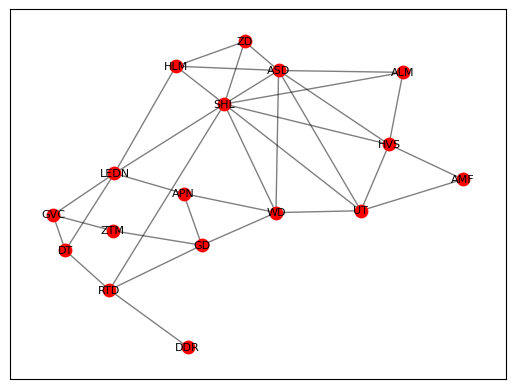

In [22]:
# create reduced graph with only red cities
G_red = nx.Graph()

# add red city nodes with original attributes
for node, data in G.nodes(data=True):
    if data.get("color") == "red":
        G_red.add_node(node, **data)

# add only the filtered red-red connections
for _, row in red_city_connections_df.iterrows():
    G_red.add_edge(
        row["from"],
        row["to"],
        weight=row["travel_time"]
    )

# positions from lat/lon
pos_red = {
    node: (data["lng"], data["lat"])
    for node, data in G_red.nodes(data=True)
}


nx.draw_networkx_edges(G_red, pos_red, alpha=0.5)
nx.draw_networkx_nodes(G_red, pos_red, node_color="red", node_size=80)
nx.draw_networkx_labels(G_red, pos_red, font_size=8)

In [23]:
print(G_red.nodes(data=True))

[('ALM', {'station': 'Almere Centrum', 'lat': 52.37503, 'lng': 5.21764, 'color': 'red'}), ('APN', {'station': 'Alphen a/d Rijn', 'lat': 52.124443054199, 'lng': 4.6577777862549, 'color': 'red'}), ('AMF', {'station': 'Amersfoort Centraal', 'lat': 52.153888702393, 'lng': 5.3705554008484, 'color': 'red'}), ('ASD', {'station': 'Amsterdam Centraal', 'lat': 52.378887176514, 'lng': 4.9002776145935, 'color': 'red'}), ('DT', {'station': 'Delft', 'lat': 52.00666809082, 'lng': 4.3563890457153, 'color': 'red'}), ('GVC', {'station': 'Den Haag Centraal', 'lat': 52.080276489258, 'lng': 4.3249998092651, 'color': 'red'}), ('DDR', {'station': 'Dordrecht', 'lat': 51.807220458984, 'lng': 4.668333530426, 'color': 'red'}), ('GD', {'station': 'Gouda', 'lat': 52.017501831055, 'lng': 4.7044444084167, 'color': 'red'}), ('HLM', {'station': 'Haarlem', 'lat': 52.38777923584, 'lng': 4.6383333206177, 'color': 'red'}), ('HVS', {'station': 'Hilversum', 'lat': 52.225833892822, 'lng': 5.1819443702698, 'color': 'red'}), (

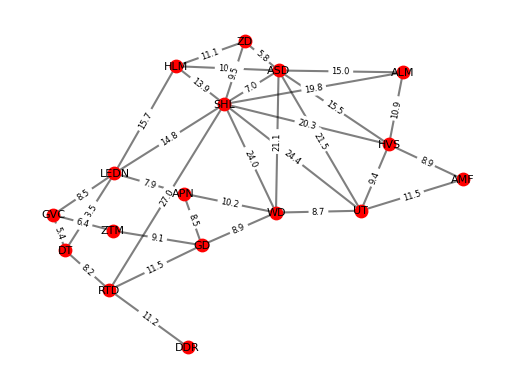

In [24]:
import matplotlib.pyplot as plt

# Draw edges first
nx.draw_networkx_edges(G_red, pos_red, alpha=0.5, width=1.5)

# Draw nodes (red only)
nx.draw_networkx_nodes(G_red, pos_red, node_color="red", node_size=80)

# Draw labels
nx.draw_networkx_labels(G_red, pos_red, font_size=8)

# Draw edge weights
edge_labels = {(u, v): f"{data['weight']:.1f}" for u, v, data in G_red.edges(data=True)}
nx.draw_networkx_edge_labels(G_red, pos_red, edge_labels=edge_labels, font_size=6)

plt.axis("off")
plt.show()

In [25]:
red_city_connections_df.drop(columns=["path"]).to_csv("network_edges_train.csv", index=False)

In [26]:
def evaluate_network_metrics(network):
    dcn = nx.degree_centrality(network)
    ccn = nx.closeness_centrality(network, distance='weight')
    bcn = nx.betweenness_centrality(network, weight='weight', normalized=True)
    lcn = nx.clustering(network, weight='weight')
    eigenvector = nx.eigenvector_centrality(network, weight='weight')

    metrics_df = pd.DataFrame({
        'Node': list(network.nodes()),
        'Station': [network.nodes[n]['station'] for n in network.nodes()],
        'DCN':  [round(dcn[n],  4) for n in network.nodes()],
        'CCN':  [round(ccn[n],  4) for n in network.nodes()],
        'BCN':  [round(bcn[n],  4) for n in network.nodes()],
        'LCN':  [round(lcn[n],  4) for n in network.nodes()],
        'EC':   [round(eigenvector[n], 4) for n in network.nodes()],
    })

    metrics_df = metrics_df.sort_values('DCN', ascending=False).reset_index(drop=True)
    return metrics_df


In [27]:
evaluate_network_metrics(G_red)

,Node,Station,DCN,CCN,BCN,LCN,EC
0,SHL,Schiphol Airport,0.5625,0.0440,0.1667,0.1543,0.5488
1,ASD,Amsterdam Centraal,0.4375,0.0417,0.0917,0.2229,0.3842
2,UT,Utrecht Centraal,0.3125,0.0416,0.1750,0.3319,0.3642
3,HVS,Hilversum,0.3125,0.0368,0.0833,0.3117,0.3086
4,LEDN,Leiden Centraal,0.3125,0.0463,0.2000,0.0864,0.1623
5,WD,Woerden,0.3125,0.0471,0.2333,0.2127,0.3309
6,RTD,Rotterdam Centraal,0.2500,0.0384,0.1667,0.0000,0.2109
7,GD,Gouda,0.2500,0.0453,0.2000,0.0565,0.0774
8,HLM,Haarlem,0.2500,0.0376,0.0000,0.2771,0.1988
9,ALM,Almere Centrum,0.1875,0.0310,0.0000,0.5275,0.2559


In [28]:
pop_df     = pd.read_csv("population_sizes.csv")
pop_lookup = dict(zip(pop_df["name"], pop_df["population"]))

# Build new graph from G_red with importance as edge weight
# importance(i, j) = (pop_i * pop_j) / travel_time²
G_pop = nx.Graph()

for node, data in G_red.nodes(data=True):
    G_pop.add_node(node, **data, population=pop_lookup.get(node, 0))

for u, v, data in G_red.edges(data=True):
    pop_u = pop_lookup.get(u, 0)
    pop_v = pop_lookup.get(v, 0)
    tt    = data["weight"]  # travel_time

    importance = (pop_u * pop_v) / (tt ** 2)

    G_pop.add_edge(u, v, weight=importance, travel_time=tt, importance=importance)

print(f"G_pop: {G_pop.number_of_nodes()} nodes, {G_pop.number_of_edges()} edges")

G_pop: 17 nodes, 34 edges


In [29]:
rows = []
for u, v, d in G_pop.edges(data=True):
    rows.append({
        "from":        u,
        "to":          v,
        "pop_from":    pop_lookup.get(u, 0),
        "pop_to":      pop_lookup.get(v, 0),
        "travel_time": round(d["travel_time"], 2),
        "importance":  round(d["importance"], 2)
    })

importance_df = (
    pd.DataFrame(rows)
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
print(importance_df.to_string(index=False))

from   to  pop_from  pop_to  travel_time   importance
 ASD  SHL    942504  140000         6.96 2.725857e+09
 ASD   ZD    942504   82410         5.82 2.289753e+09
  DT  GVC    110044  569076         5.37 2.170144e+09
 GVC  ZTM    569076  130850         6.43 1.798370e+09
 ASD  HLM    942504  168946        10.30 1.500774e+09
  DT  RTD    110044  674500         8.17 1.110658e+09
 GVC LEDN    569076  130298         8.53 1.017971e+09
 ALM  ASD    232650  942504        14.96 9.800484e+08
 ASD   UT    942504  378140        21.49 7.715187e+08
 DDR  RTD    122933  674500        11.19 6.620951e+08
 AMF   UT    163766  378140        11.52 4.670263e+08
 HVS   UT     94601  378140         9.37 4.071563e+08
  GD  RTD     77803  674500        11.54 3.942106e+08
 ASD  HVS    942504   94601        15.48 3.722594e+08
  UT   WD    378140   54208         8.74 2.682777e+08
 APN LEDN    117278  130298         7.90 2.448550e+08
 AMF  HVS    163766   94601         8.93 1.940760e+08
 ALM  HVS    232650   94601 

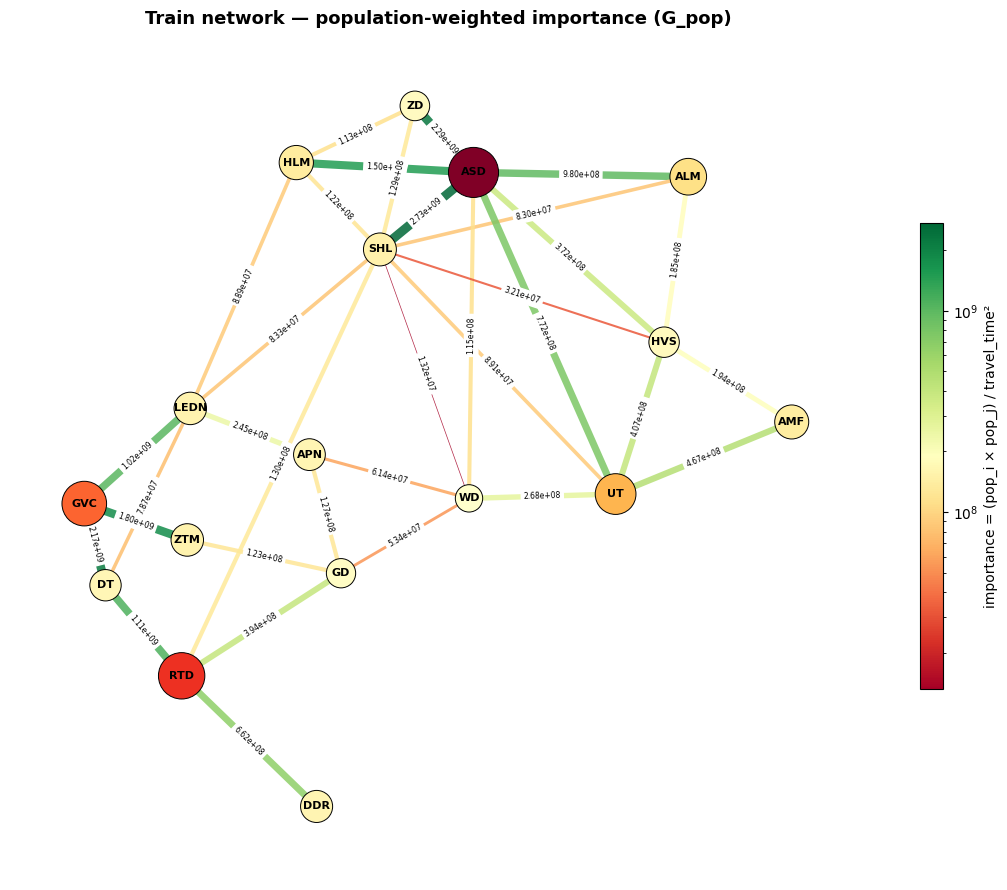

In [30]:
fig, ax = plt.subplots(figsize=(11, 9))

pops  = np.array([G_pop.nodes[n]["population"] for n in G_pop.nodes()])
sizes = 100 + 1200 * (np.sqrt(pops) / np.sqrt(pops.max()))

importances = np.array([d["importance"] for _, _, d in G_pop.edges(data=True)])
norm        = mcolors.LogNorm(vmin=importances.min(), vmax=importances.max())
cmap        = cm.RdYlGn
edge_colors = [cmap(norm(v)) for v in importances]
edge_widths = [0.5 + 6.0 * norm(v) for v in importances]

nx.draw_networkx_edges(G_pop, pos_red, ax=ax,
                       edge_color=edge_colors, width=edge_widths, alpha=0.85)
nx.draw_networkx_nodes(G_pop, pos_red, ax=ax,
                       node_size=list(sizes),
                       node_color=list(pops),
                       cmap=cm.YlOrRd,
                       edgecolors="black", linewidths=0.7)
nx.draw_networkx_labels(G_pop, pos_red, ax=ax, font_size=8, font_weight="bold")

edge_labels = {(u, v): f"{d['importance']:.2e}" for u, v, d in G_pop.edges(data=True)}
nx.draw_networkx_edge_labels(G_pop, pos_red, edge_labels=edge_labels, font_size=5.5, ax=ax)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.55,
             label="importance = (pop_i × pop_j) / travel_time²")

ax.set_title("Train network — population-weighted importance (G_pop)", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

In [31]:
def evaluate_network_metrics_pop(network):
    for u, v, d in network.edges(data=True):
        network[u][v]['distance'] = 1 / d['importance']

    dcn         = nx.degree_centrality(network)
    ccn         = nx.closeness_centrality(network, distance='distance')
    bcn         = nx.betweenness_centrality(network, weight='distance', normalized=True)
    lcn         = nx.clustering(network, weight='weight')
    eigenvector = nx.eigenvector_centrality(network, weight='weight', max_iter=1000)

    metrics_df = pd.DataFrame({
        'Node':       list(network.nodes()),
        'Station':    [network.nodes[n]['station']    for n in network.nodes()],
        'Population': [network.nodes[n]['population'] for n in network.nodes()],
        'DCN':  [dcn[n]         for n in network.nodes()],
        'CCN':  [ccn[n]         for n in network.nodes()],
        'BCN':  [bcn[n]         for n in network.nodes()],
        'LCN':  [lcn[n]         for n in network.nodes()],
        'EC':   [eigenvector[n] for n in network.nodes()],
    })

    # Min-max normalise each metric to [0, 1]
    metric_cols = ['DCN', 'CCN', 'BCN', 'LCN', 'EC']
    for col in metric_cols:
        col_min = metrics_df[col].min()
        col_max = metrics_df[col].max()
        if col_max > col_min:  # avoid division by zero if all values are equal
            metrics_df[col] = (metrics_df[col] - col_min) / (col_max - col_min)

    metrics_df = metrics_df.round(4)
    return metrics_df.sort_values('DCN', ascending=False).reset_index(drop=True)

evaluate_network_metrics_pop(G_pop)

,Node,Station,Population,DCN,CCN,BCN,LCN,EC
0,SHL,Schiphol Airport,140000,1.000,1.0000,0.8182,0.1802,0.6845
1,ASD,Amsterdam Centraal,942504,0.750,0.9920,1.0000,0.4246,1.0000
2,UT,Utrecht Centraal,378140,0.500,0.7490,0.3636,0.3125,0.2132
3,HVS,Hilversum,94601,0.500,0.4286,0.0000,0.2918,0.1243
4,LEDN,Leiden Centraal,130298,0.500,0.4902,0.1688,0.1103,0.0244
5,WD,Woerden,54208,0.500,0.1494,0.0000,0.0995,0.0408
6,RTD,Rotterdam Centraal,674500,0.375,0.8444,0.9351,0.0000,0.0242
7,GD,Gouda,77803,0.375,0.3357,0.0000,0.0210,0.0010
8,HLM,Haarlem,168946,0.375,0.7963,0.0000,0.4885,0.3891
9,ALM,Almere Centrum,232650,0.250,0.7066,0.0000,0.6128,0.2490
